# CLASS LCDM TT power spectrum in Google Colab

This notebook installs CLASS from the official public repository and uses the `classy` Python wrapper to plot the lensed CMB temperature power spectrum for a fiducial flat LCDM cosmology.

CLASS repository: https://github.com/lesgourg/class_public

In [1]:
# Install build tools and CLASS. This cell can take a few minutes in Colab.
!apt-get -qq update
!apt-get -qq install -y build-essential gfortran git
!pip -q install cython numpy matplotlib

![ -d class_public ] || git clone --depth 1 https://github.com/lesgourg/class_public.git
%cd /content/class_public
!make -j2
!pip -q install .

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/content/class_public
export CC=gcc; output=$(python -m pip install . 2>&1); \
    echo "$output"; \
    if echo "$output" | grep -q "ERROR: Cannot uninstall"; then \
        site_packages=$(python -c "import distutils.sysconfig; print(distutils.sysconfig.get_python_lib())" || python -c "import site; print(site.getsitepackages()[0])") && \
        echo "Cleaning up previous installation in: $site_packages" && \
        rm -rf $site_packages/classy* && \
        python -m pip install .; \
    fi
Processing /content/class_public
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing met

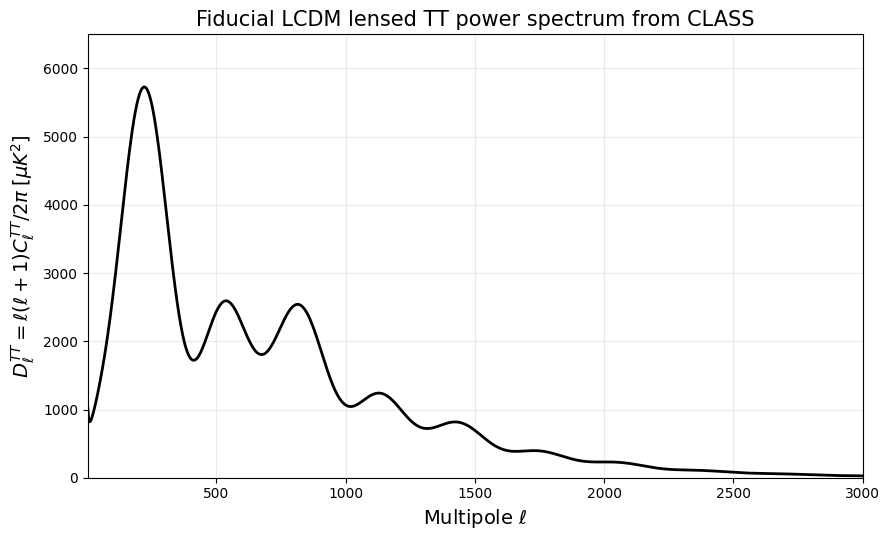

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

lmax = 3000

params = {
    "output": "tCl,lCl,pCl",
    "lensing": "yes",
    "l_max_scalars": lmax,
    "A_s": 2.101e-9,
    "n_s": 0.9649,
    "h": 0.6736,
    "omega_b": 0.02236,
    "omega_cdm": 0.1202,
    "tau_reio": 0.0544,
    "T_cmb": 2.7255,
}

cosmo = Class()
cosmo.set(params)
cosmo.compute()

cls = cosmo.lensed_cl(lmax)
ell = cls["ell"]
tt = cls["tt"]

tcmb_uK = params["T_cmb"] * 1e6
d_ell_tt = ell * (ell + 1) * tt * tcmb_uK**2 / (2 * np.pi)

mask = ell >= 2

plt.figure(figsize=(9, 5.5))
plt.plot(ell[mask], d_ell_tt[mask], color="black", lw=2)
plt.xlim(2, lmax)
plt.ylim(0, 6500)
plt.xlabel(r"Multipole $\ell$", fontsize=14)
plt.ylabel(r"$D_\ell^{TT}=\ell(\ell+1)C_\ell^{TT}/2\pi\;[\mu K^2]$", fontsize=14)
plt.title("Fiducial LCDM lensed TT power spectrum from CLASS", fontsize=15)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cosmo.struct_cleanup()
cosmo.empty()

## Fishchips Fisher forecast mini-exercise

Next we install `fishchips`, a small Fisher-forecasting package. We will follow the basic workflow in its README: define parameters and finite-difference steps, compute a fiducial CLASS cosmology plus left/right parameter variations, then ask a Planck-like CMB experiment for a Fisher matrix.

Fishchips repository: https://github.com/xzackli/fishchips-public

In [3]:
# Install fishchips from its public GitHub repository.
%cd /content
![ -d fishchips-public ] || git clone --depth 1 https://github.com/xzackli/fishchips-public.git
%cd /content/fishchips-public
!pip -q install -e .

/content
/content/fishchips-public
  Preparing metadata (setup.py) ... done


In [4]:
# Compatibility patch for recent Matplotlib versions in Colab.
# Fishchips' triangle-plot helper used the older shared-axis .join(...) API.
from pathlib import Path

util_path = Path('/content/fishchips-public/fishchips/util.py')
text = util_path.read_text()
text = text.replace(
    "ax[jj, ii].get_shared_x_axes().join(\n                                ax[jj, ii], ax[0, ii])",
    "ax[jj, ii].sharex(ax[0, ii])",
)
text = text.replace(
    "ax[jj, ii].get_shared_y_axes().join(\n                                ax[jj, ii], ax[jj, nparams-1])",
    "ax[jj, ii].sharey(ax[jj, nparams-1])",
)
util_path.write_text(text)
print('Patched fishchips.util for current Matplotlib.')


Patched fishchips.util for current Matplotlib.


### 1. Choose the parameters and CLASS template

Here we forecast constraints on three parameters while holding the rest of the cosmology fixed: scalar amplitude `A_s`, spectral index `n_s`, and optical depth `tau_reio`.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from fishchips.cosmo import Observables
from fishchips.experiments import CMB_Primary
import fishchips.util

obs = Observables(
    parameters=["A_s", "n_s","tau_reio"],
    fiducial=[2.101e-9, 0.9649,0.0544],
    left=[2.0e-9, 0.948,0.056],
    right=[2.2e-9, 0.988, 0.076],
)

classy_template = {
    "output": "tCl pCl lCl",
    "lensing": "yes",
    "l_max_scalars": 2500,
    "h": 0.6736,
    "omega_b": 0.02236,
    "omega_cdm": 0.1202,
    "T_cmb": 2.7255,
}
classy_template.update(dict(zip(obs.parameters, obs.fiducial)))

### 2. Compute the CLASS cosmologies

Fishchips stores the fiducial cosmology and the left/right parameter variations in the `Observables` object. These left/right runs are used to estimate numerical derivatives of the spectra.

In [6]:
obs.compute_cosmo(key="fiducial", classy_dict=classy_template)

for par, par_left, par_right in zip(obs.parameters, obs.left, obs.right):
    classy_left = classy_template.copy()
    classy_left[par] = par_left

    classy_right = classy_template.copy()
    classy_right[par] = par_right

    obs.compute_cosmo(key=par + "_left", classy_dict=classy_left)
    obs.compute_cosmo(key=par + "_right", classy_dict=classy_right)

list(obs.cosmos.keys())

['fiducial',
 'A_s_left',
 'A_s_right',
 'n_s_left',
 'n_s_right',
 'tau_reio_left',
 'tau_reio_right']

### 3. Define a Planck-like CMB experiment

The fishchips README uses a single-channel Planck-like TT/TE/EE experiment with a 7 arcmin beam, temperature noise of 33 uK-arcmin, polarization noise of 56 uK-arcmin, `f_sky=0.65`, and `2 <= ell <= 2500`.

In [7]:
example_planck = CMB_Primary(
    theta_fwhm=[7.0],
    sigma_T=[33.0],
    sigma_P=[56.0],
    f_sky=0.65,
    l_min=2,
    l_max=2500,
)

fisher = example_planck.get_fisher(obs)
cov = np.linalg.inv(fisher)

sigma = np.sqrt(np.diag(cov))
for name, mean, err in zip(obs.parameters, obs.fiducial, sigma):
    print(f"{name:8s} = {mean:.6g} +/- {err:.3g}")

A_s      = 2.101e-09 +/- 1.04e-11
n_s      = 0.9649 +/- 0.00218
tau_reio = 0.0544 +/- 0.00246


### 4. Plot the forecasted parameter covariance

The triangle plot shows the marginalized one- and two-sigma forecast regions from this simple Planck-like TT/TE/EE Fisher matrix.

generating new axis
['$\\mathrm{A\\_s}$', '$\\mathrm{n\\_s}$', '$\\mathrm{tau\\_reio}$']


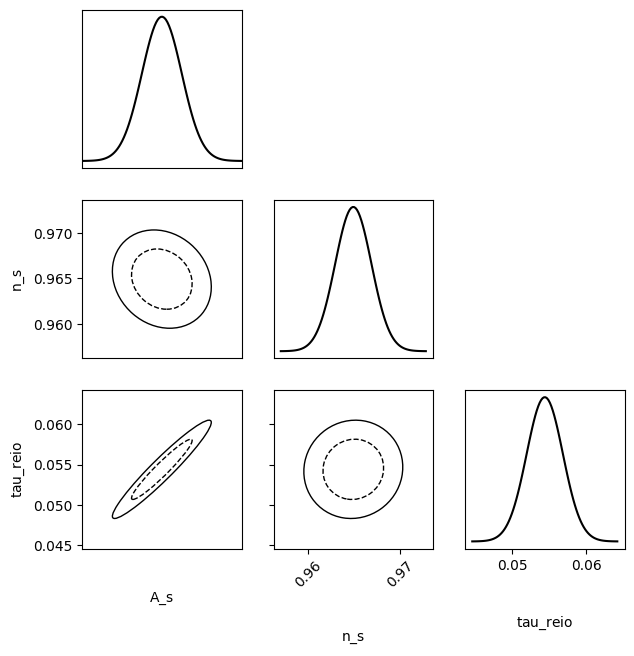

In [8]:
fig, axes = fishchips.util.plot_triangle(obs, cov)
fig.set_size_inches(7, 7)
plt.show()

# Optional: free CLASS memory when you are finished with the exercise.
# obs.clean_cosmo()

### 5. Plot the logarithmic derivative of Cl with respect to parameters

The following code allows us to inspect the derivatives of the power spectra. It tells us something about how the Cls respond to variations in these parameters, as well as allows us to inspect whether the derivatives look reasonable.

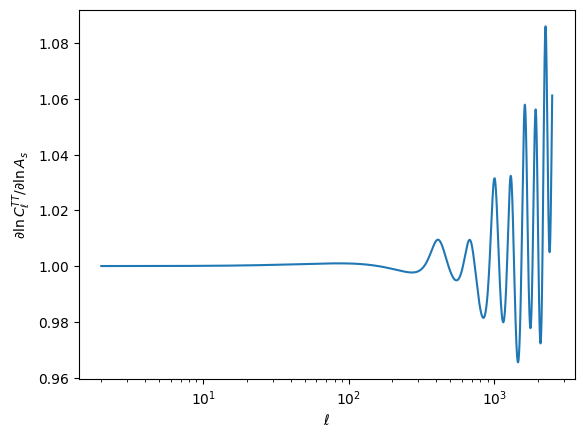

In [10]:
par = "A_s"
spec = "tt"        # "tt", "te", or "ee"
lmax = 2500

cl_fid = obs.cosmos["fiducial"].lensed_cl(lmax)[spec]
cl_left  = obs.cosmos[par + "_left"].lensed_cl(lmax)
cl_right = obs.cosmos[par + "_right"].lensed_cl(lmax)

i = obs.parameter_index[par]
dx = obs.right[i] - obs.left[i]

dcl_dpar = (cl_right[spec] - cl_left[spec]) / dx
dlncl_dlnpar = dcl_dpar[2:] / cl_fid[2:] * obs.fiducial[i]

ells = np.arange(lmax + 1)

plt.semilogx(ells[2:], dlncl_dlnpar)
plt.xlabel(r"$\ell$")
plt.ylabel(rf"$\partial \ln C_\ell^{{{spec.upper()}}}/\partial \ln {par}$")
plt.show()

### 6. Plot the forecasted parameter covariance

Now re-do the information matrix calculation but we will add in the rest of the LCDM parameters and re-compute the parameter covariance matrix. Step-sizes which are a percent or so of the fiducail are usually sufficient for a good derivative.

A_s      = 2.101e-09 +/- 1.16e-11
n_s      = 0.9649 +/- 0.00359
tau_reio = 0.0544 +/- 0.00249
H0       = 67.36 +/- 0.583
omega_b  = 0.02236 +/- 0.000143
omega_cdm = 0.1202 +/- 0.00129
generating new axis
['$\\mathrm{A\\_s}$', '$\\mathrm{n\\_s}$', '$\\mathrm{tau\\_reio}$', '$\\mathrm{H0}$', '$\\mathrm{omega\\_b}$', '$\\mathrm{omega\\_cdm}$']


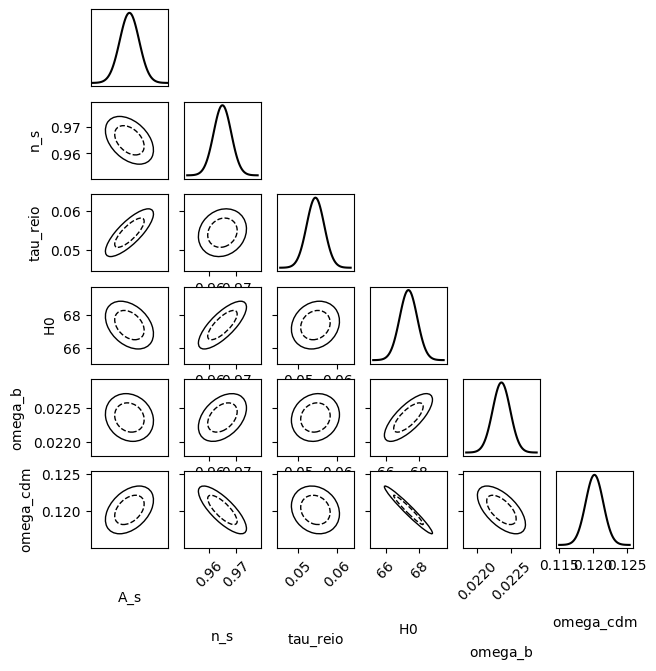

In [11]:
# Add H0, omega_cdm, omega_b using the fiducial values from before

obs = Observables(
    parameters=["A_s", "n_s", "tau_reio", "H0", "omega_b", "omega_cdm"],
    fiducial=[2.101e-9, 0.9649, 0.0544, 67.36, 0.02236, 0.1202],
    left=[2.0e-9, 0.948, 0.056, 67, 0.022, 0.118],
    right=[2.2e-9, 0.988, 0.076, 68, 0.0245, 0.122],
)

classy_template = {
    "output": "tCl pCl lCl",
    "lensing": "yes",
    "l_max_scalars": 2500,
    "T_cmb": 2.7255,
}
classy_template.update(dict(zip(obs.parameters, obs.fiducial)))

obs.compute_cosmo(key="fiducial", classy_dict=classy_template)

for par, par_left, par_right in zip(obs.parameters, obs.left, obs.right):
    classy_left = classy_template.copy()
    classy_left[par] = par_left

    classy_right = classy_template.copy()
    classy_right[par] = par_right

    obs.compute_cosmo(key=par + "_left", classy_dict=classy_left)
    obs.compute_cosmo(key=par + "_right", classy_dict=classy_right)

example_planck = CMB_Primary(
    theta_fwhm=[7.0],
    sigma_T=[33.0],
    sigma_P=[56.0],
    f_sky=0.65,
    l_min=2,
    l_max=2500,
)

fisher = example_planck.get_fisher(obs)
cov = np.linalg.inv(fisher)

sigma = np.sqrt(np.diag(cov))
for name, mean, err in zip(obs.parameters, obs.fiducial, sigma):
    print(f"{name:8s} = {mean:.6g} +/- {err:.3g}")

fig, axes = fishchips.util.plot_triangle(obs, cov)
fig.set_size_inches(7, 7)
plt.show()

In [12]:
# Temperature only

# When doing this we need to remove tau_reio from the list of parameters which are varied,
# because the TT spectrum does not contain information about tau_reio

example_planck_TT_only = CMB_Primary(
    theta_fwhm=[7.0],
    sigma_T=[33.0],
    sigma_P=[1e10], # We can effectively remove polarization by giving it a very large noise
    f_sky=0.65,
    l_min=2,
    l_max=2500,
)

fisher_TT_only = example_planck_TT_only.get_fisher(obs)

# Add Gaussian prior on tau_reio with sigma_tau = 0.007
prior_param = "tau_reio"
i = obs.parameter_index[prior_param]
sigma_prior = sigma[i]


fisher_TT_only[i, i] += 1.0 / sigma_prior**2

cov_TT_only = np.linalg.inv(fisher_TT_only)

generating new axis
['$\\mathrm{A\\_s}$', '$\\mathrm{n\\_s}$', '$\\mathrm{tau\\_reio}$', '$\\mathrm{H0}$', '$\\mathrm{omega\\_b}$', '$\\mathrm{omega\\_cdm}$']
['$\\mathrm{A\\_s}$', '$\\mathrm{n\\_s}$', '$\\mathrm{tau\\_reio}$', '$\\mathrm{H0}$', '$\\mathrm{omega\\_b}$', '$\\mathrm{omega\\_cdm}$']


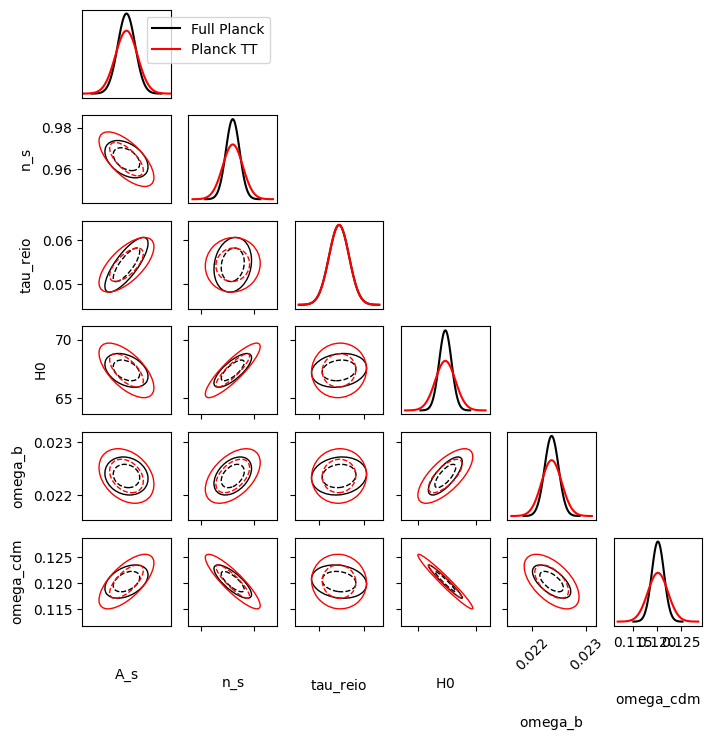

In [13]:
fig, ax = fishchips.util.plot_triangle(obs, cov);
fig, ax = fishchips.util.plot_triangle(obs, cov_TT_only, f=fig, ax=ax, color='red');

ax[0,1].plot([],[],color='black',label='Full Planck')
ax[0,1].plot([],[],color='red',label='Planck TT')
ax[0,1].legend()